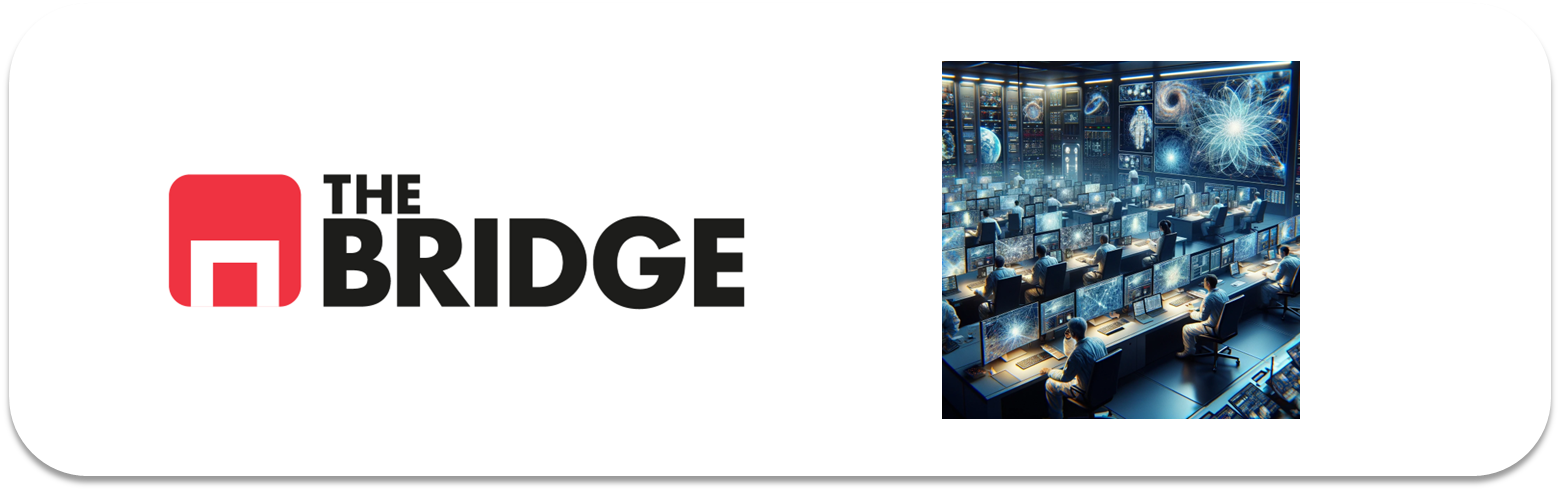

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf
import seaborn as sns 
import keras 

from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from time import time

import gc





### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 346M/346M [00:43<00:00, 8.36MB/s] 

Extracting files...


Path to dataset files: C:\Users\Luis\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [6]:
ROOT_PATH = path

In [7]:
path

'C:\\Users\\Luis\\.cache\\kagglehub\\datasets\\puneet6060\\intel-image-classification\\versions\\2'

In [8]:
os.listdir(path)

['seg_pred', 'seg_test', 'seg_train']

In [9]:
TRAIN_PATH = ROOT_PATH + "/seg_train/seg_train/"
TEST_PATH = ROOT_PATH + "/seg_test/seg_test/"

In [10]:
os.listdir(TRAIN_PATH)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

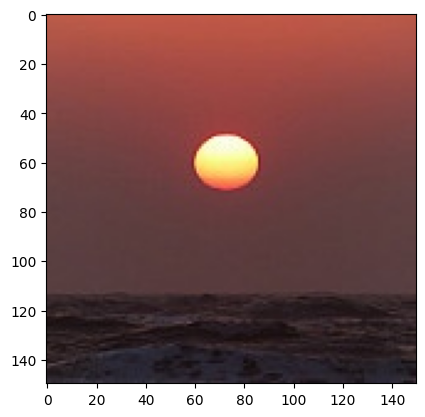

In [15]:
plt.imshow(imread(TRAIN_PATH + "/sea/"+ "11321.jpg"))
plt.show()

In [16]:
img_width = img_heigth = 75

In [17]:
def read_data(directorio, reshape_dim = (img_width, img_heigth)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        print(folder)
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 75x75

                X.append(image)
                y.append(folder)

    return np.array(X), np.array(y)




In [18]:
def show_images_batch(paisajes, names = [], n_cols = 5, size_scale = 2):
    n_rows = ((len(paisajes) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1 * size_scale))
    for index, paisaje in enumerate(paisajes):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(paisaje, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

In [19]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

buildings
forest
glacier
mountain
sea
street
buildings
forest
glacier
mountain
sea
street


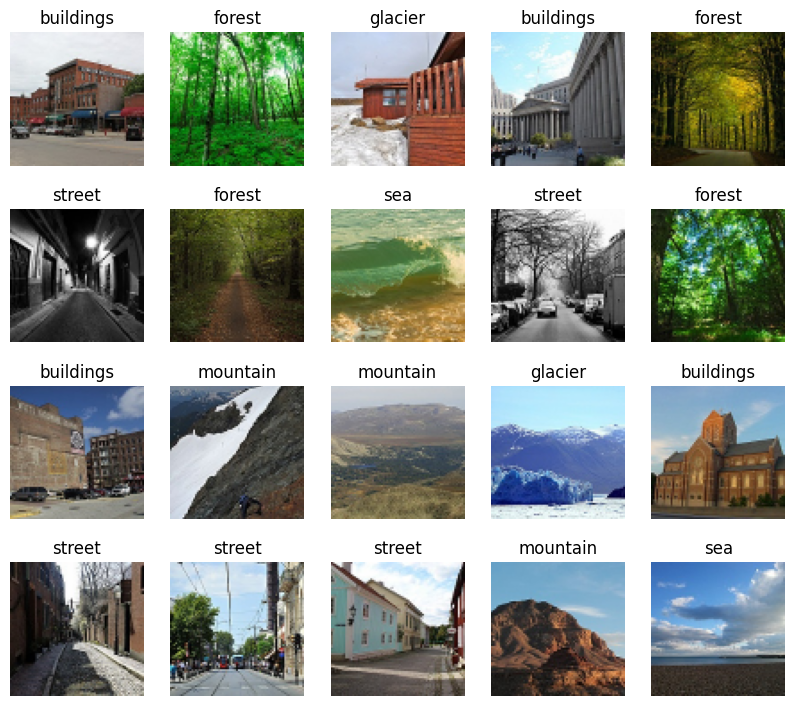

In [20]:
indices = np.random.randint(0,len(X_train),20)
show_images_batch(X_train[indices], names = y_train[indices], n_cols = 5)

In [23]:
X_train = (X_train/127.5) - 1.0
X_test = (X_test/127.5) - 1.0

In [22]:
from keras.applications import InceptionV3

In [29]:
img_width = img_heigth = 75

base_model = InceptionV3(include_top=False, weights="imagenet",input_shape=(img_width,img_heigth,3))

for layer in base_model.layers:
    layer.trainable = False



def prepare_model(base_model = base_model): 
    
    x = keras.layers.Flatten()(base_model.output)
    x = keras.layers.Dense(2048, activation='relu')(x)
    x = keras.layers.Dropout(rate = 0.25)(x)
    output = keras.layers.Dense(6, activation='softmax')(x)

    model = keras.Model(base_model.input, output)
    model.compile(
        optimizer = "adam",
        loss = 'sparse_categorical_crossentropy', 
        metrics = ['acc']
        )
    return model

model = prepare_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 37, 37,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_188[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 35, 35,    │      9,216 │ activation_188[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_189[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 35, 35,    │     18,432 │ activation_189[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_190[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 17, 17,    │          0 │ activation_190[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 17, 17,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_191[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 15, 15,    │    138,240 │ activation_191[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_192[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 4,208,646 (16.05 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [30]:
instancias_train = len(X_train)
for i in range(1,5):
    print(f"Batch_size: {32*i}, num per epoch: {round(instancias_train*0.8/(32*i))}")

Batch_size: 32, num per epoch: 351
Batch_size: 64, num per epoch: 175
Batch_size: 96, num per epoch: 117
Batch_size: 128, num per epoch: 88


In [31]:
targets = pd.Series(y_train)

In [33]:
mapa = {tipo:indice for indice,tipo in enumerate(targets.unique())}
mapa

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [34]:
y_train_num = np.array([mapa[y] for y in y_train])
y_test_num = np.array([mapa[y] for y in y_test])

In [35]:
from sklearn.utils import shuffle
X_train_s, y_train_s = shuffle(X_train, y_train_num)


In [36]:
batch_size = 128

In [37]:
earlyS = keras.callbacks.EarlyStopping(patience= 10, restore_best_weights= True)

In [38]:
t_zero = time()
model = prepare_model()
history = model.fit(X_train_s,
                    y_train_s,
                    batch_size = batch_size,
                    validation_split=0.2,
                    epochs=40,
                    callbacks = [earlyS])
tiempo = round(time() - t_zero, 3)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 248ms/step - acc: 0.3672 - loss: 1.7884 - val_acc: 0.4795 - val_loss: 1.3108
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - acc: 0.4999 - loss: 1.2405 - val_acc: 0.5205 - val_loss: 1.1749
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 235ms/step - acc: 0.5295 - loss: 1.1620 - val_acc: 0.5319 - val_loss: 1.1832
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 246ms/step - acc: 0.5483 - loss: 1.1300 - val_acc: 0.5144 - val_loss: 1.1750
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 254ms/step - acc: 0.5541 - loss: 1.1082 - val_acc: 0.5675 - val_loss: 1.0835
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 235ms/step - acc: 0.5663 - loss: 1.0771 - val_acc: 0.5814 - val_loss: 1.0573
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 258ms/step - acc: 0.5682 - loss: 1.0800 - val_acc: 0.5889 - val_loss: 1.0524
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 249ms/step - acc: 0.5742 - loss: 1.0607 - val_acc: 0.5486 - val_loss: 1.1078
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/

In [39]:
model.evaluate(X_test,y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - acc: 0.6327 - loss: 0.9539


[0.9539090394973755, 0.6326666474342346]

In [40]:
y_pred = [np.argmax(prediction) for prediction in model.predict(X_test) ]

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step


In [41]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
inverse_map = {valor:clave for clave,valor in mapa.items()}
y_test_labels = [inverse_map[y] for y in y_test_num]
y_pred_labels = [inverse_map[y] for y in y_pred]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

   buildings       0.57      0.64      0.60       437
      forest       0.78      0.81      0.79       474
     glacier       0.53      0.64      0.58       553
    mountain       0.58      0.55      0.56       525
         sea       0.68      0.55      0.61       510
      street       0.71      0.62      0.66       501

    accuracy                           0.63      3000
   macro avg       0.64      0.64      0.64      3000
weighted avg       0.64      0.63      0.63      3000



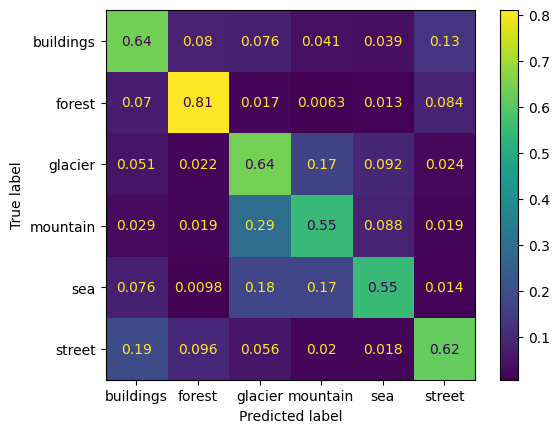

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels,normalize="true")

In [44]:
img_width = img_heigth = 75

base_model = InceptionV3(include_top=False, weights="imagenet",input_shape=(img_width,img_heigth,3))




def prepare_model(base_model = base_model): 
    
    x = keras.layers.Flatten()(base_model.output)
    x = keras.layers.Dense(2048, activation='relu')(x)
    x = keras.layers.Dropout(rate = 0.25)(x)
    output = keras.layers.Dense(6, activation='softmax')(x)

    model = keras.Model(base_model.input, output)
    model.compile(
        optimizer = "adam",
        loss = 'sparse_categorical_crossentropy', 
        metrics = ['acc']
        )
    return model

model = prepare_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_282 (Conv2D) │ (None, 37, 37,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_282[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_282      │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_283 (Conv2D) │ (None, 35, 35,    │      9,216 │ activation_282[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_283[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_283      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_284 (Conv2D) │ (None, 35, 35,    │     18,432 │ activation_283[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_284[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_284      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 17, 17,    │          0 │ activation_284[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_285 (Conv2D) │ (None, 17, 17,    │      5,120 │ max_pooling2d_12… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_285[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_285      │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_286 (Conv2D) │ (None, 15, 15,    │    138,240 │ activation_285[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_286[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_286      │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 25,976,998 (99.09 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [45]:
t_zero = time()
model = prepare_model()
history = model.fit(X_train_s,
                    y_train_s,
                    batch_size = batch_size,
                    validation_split=0.2,
                    epochs=40,
                    callbacks = [earlyS])
tiempo = round(time() - t_zero, 3)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - acc: 0.6037 - loss: 1.1526 - val_acc: 0.1585 - val_loss: 1.7995
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 934ms/step - acc: 0.8064 - loss: 0.7028 - val_acc: 0.1564 - val_loss: 3.5003
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 83s 938ms/step - acc: 0.7547 - loss: 0.8570 - val_acc: 0.1585 - val_loss: 5541.1729
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 83s 938ms/step - acc: 0.8272 - loss: 0.5966 - val_acc: 0.3042 - val_loss: 1.8836
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 934ms/step - acc: 0.8601 - loss: 0.4632 - val_acc: 0.1689 - val_loss: 8.9504
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 934ms/step - acc: 0.8820 - loss: 0.3650 - val_acc: 0.2786 - val_loss: 1.7532
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 83s 938ms/step - acc: 0.9013 - loss: 0.3096 - val_acc: 0.1617 - val_loss: 3.6841
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 83s 946ms/step - acc: 0.8706 - loss: 0.4232 - val_acc: 0.1585 - val_loss: 30154.4219
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 9

In [46]:
y_pred = [np.argmax(prediction) for prediction in model.predict(X_test) ]

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step


In [47]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
inverse_map = {valor:clave for clave,valor in mapa.items()}
y_test_labels = [inverse_map[y] for y in y_test_num]
y_pred_labels = [inverse_map[y] for y in y_pred]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

   buildings       0.00      0.00      0.00       437
      forest       0.00      0.00      0.00       474
     glacier       0.00      0.00      0.00       553
    mountain       0.00      0.00      0.00       525
         sea       0.17      1.00      0.29       510
      street       0.00      0.00      0.00       501

    accuracy                           0.17      3000
   macro avg       0.03      0.17      0.05      3000
weighted avg       0.03      0.17      0.05      3000



c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

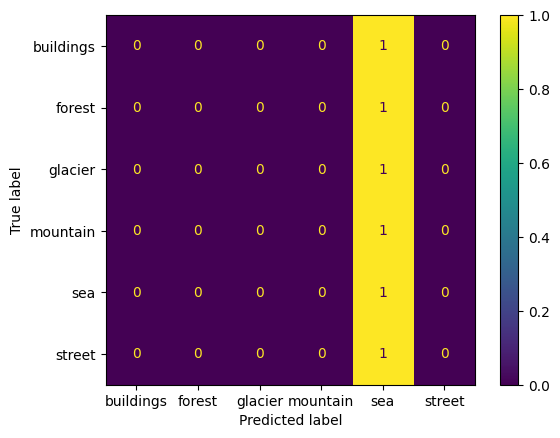

In [48]:
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels,normalize="true")